<a href="https://colab.research.google.com/github/M4XJUNG/AIF-Financial-Time-Series/blob/main/URA_2nd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# =========================
# 셀 1) 작업 디렉토리 자동 탐색/clone + GPU 확인  (← 여기부터 교체)
# =========================
import os, sys, glob, subprocess
from pathlib import Path

# 1) /content 아래에서 Time-o1 후보 디렉토리 자동 탐색
candidates = []
for p in glob.glob("/content/*"):
    if os.path.isdir(p) and ("time" in p.lower() and "o1" in p.lower()):
        candidates.append(p)

REPO = None
if candidates:
    # 가장 그럴듯한 것 우선
    candidates = sorted(candidates, key=lambda x: (0 if x.endswith("Time-o1") else 1, x))
    REPO = Path(candidates[0])
else:
    REPO = Path("/content/Time-o1")

# 2) 없으면 clone
if not REPO.exists():
    print(f"REPO not found: {REPO} -> cloning...")
    subprocess.check_call(["git", "clone", "https://github.com/Master-PLC/Time-o1", str(REPO)])

# 3) 이동
%cd {str(REPO)}

# 4) GPU 확인
import torch
print("python:", sys.version)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


/content/Time-o1
python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
torch: 2.9.0+cu126
cuda available: True
gpu: Tesla T4


In [25]:
# =========================
# 셀 2) (선택) pip 다운로드 캐시를 Drive에 저장 (세션 끊겨도 설치 빨라짐)
#  - Drive 쓰기 싫으면 이 셀 스킵 가능
# =========================
from google.colab import drive
from pathlib import Path
import os

drive.mount("/content/drive")

PIP_CACHE_DIR = Path("/content/drive/MyDrive/pip-cache")
PIP_CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["PIP_CACHE_DIR"] = str(PIP_CACHE_DIR)
print("PIP_CACHE_DIR =", os.environ["PIP_CACHE_DIR"])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PIP_CACHE_DIR = /content/drive/MyDrive/pip-cache


In [26]:
# =========================
# 셀 3) 누락 패키지 설치 (setproctitle 등)
#  - torch는 건드리지 않음
# =========================
!pip -q install -U pip
!pip -q install setproctitle torchmetrics performer_pytorch reformer_pytorch thop einops pandas scikit-learn matplotlib tqdm pyyaml psutil

print("✅ pip installs done")


✅ pip installs done


In [27]:
# =========================
# 셀 4) 레포 내부 CSV 자동 탐색 + 우선순위 후보 리스트 출력
#  - dataset/**, data/**, 전체 /** 스캔
# =========================
import glob
from pathlib import Path

def find_csv_candidates(root="."):
    root = Path(root).resolve()
    patterns = [
        str(root / "dataset/**/*.csv"),
        str(root / "data/**/*.csv"),
        str(root / "**/*.csv"),
    ]
    seen = set()
    out = []
    for pat in patterns:
        for p in glob.glob(pat, recursive=True):
            rp = str(Path(p).resolve())
            if rp in seen:
                continue
            seen.add(rp)
            try:
                sz = Path(rp).stat().st_size
            except:
                sz = 0
            out.append((rp, sz))
    return out

def score(path: str, sz: int):
    p = path.lower()
    s = 0
    if "etth1" in p: s += 1000
    if "etth2" in p: s += 900
    if "ettm1" in p: s += 800
    if "ettm2" in p: s += 700
    if "/dataset/" in p: s += 200
    if "/data/" in p: s += 150
    s += int(sz / 1e6)  # MB
    return s

cands = find_csv_candidates(".")
cands_sorted = sorted(cands, key=lambda x: score(x[0], x[1]), reverse=True)

print(f"found {len(cands_sorted)} csv files")
for i, (p, sz) in enumerate(cands_sorted[:30], 1):
    print(f"{i:02d}. {sz/1e6:7.1f}MB  {p}")

CSV_PATH = cands_sorted[0][0] if cands_sorted else None
print("\nAUTO SELECT =", CSV_PATH)


found 4 csv files
01.     2.6MB  /content/Time-o1/dataset/ETT-small/ETTh1.csv
02.     2.4MB  /content/Time-o1/dataset/ETT-small/ETTh2.csv
03.    10.4MB  /content/Time-o1/dataset/ETT-small/ETTm1.csv
04.     9.7MB  /content/Time-o1/dataset/ETT-small/ETTm2.csv

AUTO SELECT = /content/Time-o1/dataset/ETT-small/ETTh1.csv


In [28]:
# =========================
# 셀 5) ETTh1.csv 없으면 자동 다운로드 + run.py 인자에 맞는 root_path/data_path 세팅
#  - "data 폴더 없음" 에러도 제거
# =========================
from pathlib import Path

Path("./data").mkdir(parents=True, exist_ok=True)

target = Path("./dataset/ETT-small/ETTh1.csv")
target.parent.mkdir(parents=True, exist_ok=True)

if not target.exists():
    url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
    !wget -q -O {str(target)} {url}
    print("✅ downloaded:", target.resolve())
else:
    print("✅ exists:", target.resolve())

ROOT_PATH = str(target.parent.resolve()) + "/"
DATA_PATH = target.name

print("ROOT_PATH =", ROOT_PATH)
print("DATA_PATH =", DATA_PATH)


✅ exists: /content/Time-o1/dataset/ETT-small/ETTh1.csv
ROOT_PATH = /content/Time-o1/dataset/ETT-small/
DATA_PATH = ETTh1.csv


In [29]:
# =========================
# 셀 6) (REPLACE) 의존성 빠진 것만 최소 설치 + run.py 지원 옵션을 '소스에서' 정적으로 수집
#   - run.py -h 절대 안 씀 (argparse help 버그 회피)
# =========================
import importlib, subprocess, re
from pathlib import Path
import torch

# 1) 누락 모듈만 설치 (이미 설치돼 있으면 건드리지 않음)
REQ = {
    "patoolib": "patool",    # 모듈명 != pip명
    "sktime": "sktime",
    "robustica": "robustica",
}

for mod, pkg in REQ.items():
    try:
        importlib.import_module(mod)
        print(f"✅ {mod} OK")
    except Exception as e:
        print(f"🔧 installing {pkg} (missing {mod})")
        subprocess.run(["pip", "-q", "install", pkg], check=False)

# torch_geometric은 torch 버전에 맞는 wheel 인덱스로 깔아야 안전함
try:
    import torch_geometric  # noqa
    print("✅ torch_geometric OK")
except Exception:
    tv = torch.__version__.split("+")[0]        # "2.4.0"
    cu = (torch.__version__.split("+")[1] if "+" in torch.__version__ else "cpu")  # "cu118" or "cpu"
    if cu == "cpu":
        whl = f"https://data.pyg.org/whl/torch-{tv}+cpu.html"
    else:
        whl = f"https://data.pyg.org/whl/torch-{tv}+{cu}.html"

    print("🔧 installing PyG wheels from:", whl)
    subprocess.run(
        ["pip", "-q", "install",
         "torch_geometric", "torch_scatter", "torch_sparse", "torch_cluster", "torch_spline_conv",
         "-f", whl],
        check=False,
    )

# 2) run.py에서 지원 옵션을 '정적으로' 파싱
runpy = Path("run.py")
assert runpy.exists(), "run.py 가 현재 디렉토리에 없습니다. (셀 1에서 %cd 확인)"

txt = runpy.read_text(encoding="utf-8", errors="ignore")

# parser.add_argument("--xxx", ...) 형태를 전부 수집
SUPPORTED_FLAGS = set(re.findall(r"add_argument\(\s*['\"](--[A-Za-z0-9_\-]+)['\"]", txt))

# (참고) '--help' 같은 기본 옵션은 argparse가 알아서 처리하니 굳이 포함할 필요 없음
print(f"✅ parsed {len(SUPPORTED_FLAGS)} flags from run.py")
print("sample:", sorted(list(SUPPORTED_FLAGS))[:30])


✅ patoolib OK
✅ sktime OK
✅ robustica OK
🔧 installing PyG wheels from: https://data.pyg.org/whl/torch-2.9.0+cu126.html
✅ parsed 164 flags from run.py
sample: ['--CSCM', '--ablation', '--activation', '--add_noise', '--affine', '--align_type', '--alpha', '--anomaly_ratio', '--auxi_batch_size', '--auxi_lambda', '--auxi_loss', '--auxi_mode', '--auxi_type', '--batch_size', '--begin_order', '--c_out', '--cf_depth', '--cf_dim', '--cf_drop', '--cf_head_dim', '--cf_heads', '--cf_mlp', '--cf_p', '--cf_patch_len', '--cf_weight_decay', '--channel_independence', '--checkpoints', '--cutoff_freq_percentage', '--d_ff', '--d_layers']


In [30]:
# =========================
# 셀 6.5) (NEW) 셀 7 실행 전: 의존성/임포트 병목 자동 점검
#   - torch_geometric이 깨지면, "코드 패치로 import 강제 의존성 제거" 루트로 갈 수 있게 준비
# =========================
import importlib, subprocess, sys, textwrap

def ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
        print(f"✅ {name} OK")
        return True
    except Exception as e:
        print(f"🔧 install {pkg} (missing {name})")
        subprocess.run(["pip", "-q", "install", pkg], check=False)
        try:
            importlib.import_module(name)
            print(f"✅ {name} OK after install")
            return True
        except Exception as e2:
            print(f"❌ still missing {name}: {e2}")
            return False

# 이미 네가 겪었던 것들
ensure("patool", "patoolib")
ensure("sktime", "sktime")
ensure("robustica", "robustica")

print("✅ basic deps checked")


✅ patoolib OK
✅ sktime OK
✅ robustica OK
✅ basic deps checked


In [31]:
# =========================
# 셀 6.6) (NEW) torch_geometric 설치 시도 (가능하면 설치)
#   - 실패해도 다음 셀(6.7)에서 "코드 패치로 회피" 가능
# =========================
import torch, subprocess, importlib

def try_import(name):
    try:
        importlib.import_module(name)
        return True
    except Exception:
        return False

if try_import("torch_geometric"):
    print("✅ torch_geometric already OK")
else:
    tv = torch.__version__.split("+")[0]                  # e.g. 2.4.0
    cu = torch.__version__.split("+")[1] if "+" in torch.__version__ else "cpu"  # e.g. cu118
    whl = f"https://data.pyg.org/whl/torch-{tv}+{cu}.html" if cu != "cpu" else f"https://data.pyg.org/whl/torch-{tv}+cpu.html"
    print("🔧 Trying PyG install from:", whl)

    subprocess.run(
        ["pip", "-q", "install",
         "torch_scatter", "torch_sparse", "torch_cluster", "torch_spline_conv", "torch_geometric",
         "-f", whl],
        check=False,
    )

    if try_import("torch_geometric"):
        print("✅ torch_geometric OK after install")
    else:
        print("❌ torch_geometric still NOT importable (will patch repo imports in next cell)")


🔧 Trying PyG install from: https://data.pyg.org/whl/torch-2.9.0+cu126.html
❌ torch_geometric still NOT importable (will patch repo imports in next cell)


In [32]:
# =========================
# 셀 6.7) (NEW) torch_geometric이 깨져도 학습이 되게: models/__init__.py import 폭탄 방지 패치
#   - Time-o1 레포가 "모든 모델을 한 번에 import"하는 구조면,
#     안 쓰는 모델(AdaMSHyper 등) 때문에도 죽음.
#   - 이 셀은 torch_geometric이 없을 때만 "해당 모델 import를 try/except로 감싼다".
# =========================
import importlib, pathlib, re

def can_import(name):
    try:
        importlib.import_module(name)
        return True
    except Exception:
        return False

if can_import("torch_geometric"):
    print("✅ torch_geometric OK -> patch not needed")
else:
    init_path = pathlib.Path("models/__init__.py")
    assert init_path.exists(), "models/__init__.py 없음 (레포 구조 확인 필요)"

    src = init_path.read_text(encoding="utf-8", errors="ignore")

    # 이미 패치했으면 중복 방지
    if "PATCHED_TORCH_GEOMETRIC_GUARD" in src:
        print("✅ models/__init__.py already patched")
    else:
        # AdaMSHyper import 라인/블록을 try/except로 감싸기 (최소 침습)
        # 케이스가 2가지라(단일 import vs 묶음 import) 둘 다 커버
        patched = src

        # 1) "from . import (... AdaMSHyper ...)" 묶음에서 AdaMSHyper만 제거 (가장 안전)
        #    => AdaMSHyper 문자열만 제거하고 콤마 정리
        if "AdaMSHyper" in patched:
            patched = re.sub(r"\bAdaMSHyper\b\s*,?\s*", "", patched)
            patched = re.sub(r",\s*,", ", ", patched)

        # 2) 혹시 별도 import가 있다면 주석 처리
        patched = re.sub(r"^(\s*from\s+\.\s+import\s+AdaMSHyper.*)$", r"# PATCHED_TORCH_GEOMETRIC_GUARD: \1", patched, flags=re.MULTILINE)
        patched = re.sub(r"^(\s*import\s+AdaMSHyper.*)$", r"# PATCHED_TORCH_GEOMETRIC_GUARD: \1", patched, flags=re.MULTILINE)

        # 패치 마커
        patched = "# PATCHED_TORCH_GEOMETRIC_GUARD\n" + patched

        # 백업 저장
        bak = init_path.with_suffix(".py.bak")
        if not bak.exists():
            bak.write_text(src, encoding="utf-8")
            print("✅ backup created:", bak)

        init_path.write_text(patched, encoding="utf-8")
        print("✅ patched models/__init__.py to avoid torch_geometric hard dependency")


✅ patched models/__init__.py to avoid torch_geometric hard dependency


In [33]:
# =========================
# (NEW) Fix Cell: models/__init__.py 문법 복구 + Fredformer만 로드하도록 최소화
#   - 지금 난 SyntaxError를 여기서 제거해야 run.py가 시작됨
# =========================
from pathlib import Path
import textwrap

p = Path("/content/Time-o1/models/__init__.py")
assert p.exists(), f"not found: {p}"

# 혹시를 위해 현재 파일 백업
bak = p.with_suffix(".py.broken.bak")
bak.write_text(p.read_text(encoding="utf-8", errors="ignore"), encoding="utf-8")
print("✅ backed up broken file ->", bak)

new_src = textwrap.dedent("""
    # Auto-generated minimal model registry for Colab.
    # Purpose: avoid hard imports of every model (some require extra deps like torch_geometric).
    # We only load what we need: Fredformer.

    import importlib
    import inspect

    def _load_class(module_name: str, prefer_names=("Model",)):
        m = importlib.import_module(module_name)
        # 1) Prefer common class names
        for nm in prefer_names:
            obj = getattr(m, nm, None)
            if inspect.isclass(obj):
                return obj
        # 2) Otherwise pick a class that looks like a model
        for name, obj in m.__dict__.items():
            if inspect.isclass(obj) and obj.__module__ == m.__name__:
                return obj
        raise ImportError(f"No model class found in {module_name}")

    # Required by exp/exp_basic.py
    MODEL_DICT = {}

    # Fredformer is required for your run command: --model Fredformer
    try:
        FredformerCls = _load_class(__name__ + ".Fredformer", prefer_names=("Model", "Fredformer"))
        MODEL_DICT["Fredformer"] = FredformerCls
    except Exception as e:
        raise ImportError("Failed to import Fredformer model. Check models/Fredformer.py") from e
""").lstrip()

p.write_text(new_src, encoding="utf-8")
print("✅ rewrote:", p)

# sanity check: compile
compile(p.read_text(encoding="utf-8"), str(p), "exec")
print("✅ models/__init__.py syntax OK")


✅ backed up broken file -> /content/Time-o1/models/__init__.py.broken.bak
✅ rewrote: /content/Time-o1/models/__init__.py
✅ models/__init__.py syntax OK


In [34]:
# =========================
# Cell 8 (REPLACE) sanity check (run.py -h 호출 제거)
#   - run.py -h 는 argparse help 버그로 깨져서 여기서 확인하지 않음
#   - 대신 핵심 import / 데이터 / 모델 레지스트리만 검증
# =========================
import os, subprocess
from pathlib import Path

TIME_O1 = Path("/content/Time-o1")
assert TIME_O1.exists(), "Time-o1 경로가 없습니다."
os.chdir(TIME_O1)
print("CWD:", os.getcwd())

# 데이터 경로 확정
ROOT_PATH = "/content/Time-o1/dataset/ETT-small/"
DATA_PATH = "ETTh1.csv"
csv_path = Path(ROOT_PATH) / DATA_PATH
assert csv_path.exists(), f"CSV not found: {csv_path}"
print("✅ CSV:", csv_path)

# 모델 레지스트리 확인
from models import MODEL_DICT
print("✅ MODEL_DICT keys:", list(MODEL_DICT.keys()))
assert "Fredformer" in MODEL_DICT, "MODEL_DICT에 Fredformer가 없습니다."

# run.py를 실행하지 않고(=argparse 안 타게) 핵심 모듈 import만 체크
p = subprocess.run(
    ["python", "-c", "import exp, data_provider, models; print('✅ imports ok')"],
    capture_output=True, text=True
)
print(p.stdout.strip())
if p.returncode != 0:
    print("---- STDERR (tail) ----")
    print("\n".join(p.stderr.splitlines()[-80:]))
    raise RuntimeError("핵심 import 실패. 위 tail 확인.")


CWD: /content/Time-o1
✅ CSV: /content/Time-o1/dataset/ETT-small/ETTh1.csv
✅ MODEL_DICT keys: ['Fredformer']
✅ imports ok


In [35]:
# =========================
# Cell 8.1 (OPTIONAL) run.py -h 버그 패치: help= 라인에 있는 %를 %%로 escape
#   - 이거 실행하면 `python run.py -h`도 정상 동작하게 만들 확률이 높음
# =========================
from pathlib import Path
import re, subprocess, os

os.chdir("/content/Time-o1")
rp = Path("run.py")
src = rp.read_text(encoding="utf-8", errors="ignore").splitlines(True)

patched = []
changed = 0
for line in src:
    if "help=" in line and "%" in line:
        # 이미 %%인 경우 유지하려고: 일단 % -> %% 하고, 생긴 %%%%는 %%로 되돌림
        new = line.replace("%", "%%")
        while "%%%%" in new:
            new = new.replace("%%%%", "%%")
        if new != line:
            changed += 1
        patched.append(new)
    else:
        patched.append(line)

bak = rp.with_suffix(".py.helpbug.bak")
bak.write_text("".join(src), encoding="utf-8")
rp.write_text("".join(patched), encoding="utf-8")
print(f"✅ patched run.py help lines: {changed} (backup: {bak})")

# -h 재검증
p = subprocess.run(["python", "run.py", "-h"], capture_output=True, text=True)
print("run.py -h rc:", p.returncode)
if p.returncode != 0:
    print("---- STDERR (tail) ----")
    print("\n".join(p.stderr.splitlines()[-80:]))
    raise RuntimeError("run.py -h still failing")
print("✅ run.py -h OK")


✅ patched run.py help lines: 0 (backup: run.py.helpbug.bak)
run.py -h rc: 0
✅ run.py -h OK


In [36]:
# =========================
# Cell 8.2) models/__init__.py 다시 교체: MODEL_DICT는 "모듈"을 가리키게
#   - exp_basic.py가 기대하는 형태: MODEL_DICT[name].Model(args)
# =========================
from pathlib import Path
import textwrap, importlib, inspect

p = Path("/content/Time-o1/models/__init__.py")
assert p.exists(), f"not found: {p}"

bak = p.with_suffix(".py.classdict.bak")
bak.write_text(p.read_text(encoding="utf-8", errors="ignore"), encoding="utf-8")
print("✅ backup ->", bak)

new_src = textwrap.dedent("""
    # Auto-generated minimal model registry for Colab.
    # IMPORTANT: exp_basic.py expects: MODEL_DICT[name].Model(args)
    # Therefore MODEL_DICT values must be MODULES (not classes).

    import importlib

    MODEL_DICT = {}

    # Fredformer only
    _mod = importlib.import_module(__name__ + ".Fredformer")
    # sanity: must provide class `Model`
    if not hasattr(_mod, "Model"):
        raise ImportError("models/Fredformer.py must define class `Model` (missing).")
    MODEL_DICT["Fredformer"] = _mod
""").lstrip()

p.write_text(new_src, encoding="utf-8")
print("✅ rewrote:", p)

# sanity: import and check shape
import sys
if "models" in sys.modules:
    import importlib as _il
    _il.reload(sys.modules["models"])

from models import MODEL_DICT
print("✅ MODEL_DICT keys:", list(MODEL_DICT.keys()))
print("✅ Fredformer entry type:", type(MODEL_DICT["Fredformer"]))

# verify callable path exp expects
assert hasattr(MODEL_DICT["Fredformer"], "Model"), "Fredformer module has no Model"
print("✅ MODEL_DICT['Fredformer'].Model exists")


✅ backup -> /content/Time-o1/models/__init__.py.classdict.bak
✅ rewrote: /content/Time-o1/models/__init__.py
✅ MODEL_DICT keys: ['Fredformer']
✅ Fredformer entry type: <class 'module'>
✅ MODEL_DICT['Fredformer'].Model exists


In [37]:
# =========================
# Cell 8.3) exp_long_term_forecasting.py 패치
#   - loss가 int/float로 떨어져도 isnan/isinf에서 안죽게 강제 Tensor化
# =========================
from pathlib import Path
import re

fp = Path("/content/Time-o1/exp/exp_long_term_forecasting.py")
assert fp.exists(), f"not found: {fp}"

src = fp.read_text(encoding="utf-8", errors="ignore").splitlines(True)

# 백업
bak = fp.with_suffix(".py.isnanfix.bak")
bak.write_text("".join(src), encoding="utf-8")
print("✅ backup ->", bak)

out = []
patched = 0

for line in src:
    out.append(line)

    # 정확히 이 라인 바로 위에 캐스팅 코드 삽입
    if re.search(r"if\s+torch\.isnan\(\s*loss\s*\)\s+or\s+torch\.isinf\(\s*loss\s*\)\s*:", line):
        indent = re.match(r"^(\s*)", line).group(1)
        out.insert(
            -1,
            indent
            + "if not torch.is_tensor(loss):\n"
            + indent
            + "    loss = torch.tensor(loss, device=self.device, dtype=torch.float32)\n"
        )
        patched += 1

fp.write_text("".join(out), encoding="utf-8")
print("✅ patched lines:", patched)

# 간단 컴파일 체크
compile(fp.read_text(encoding="utf-8"), str(fp), "exec")
print("✅ compile OK")


✅ backup -> /content/Time-o1/exp/exp_long_term_forecasting.py.isnanfix.bak
✅ patched lines: 1
✅ compile OK


In [38]:
# =========================
# Cell 8.4) exp_long_term_forecasting.py 패치
#   - loss.backward() 직전에 "loss가 grad 없으면" main loss(loss_tmp 등)로 강제 교체
# =========================
from pathlib import Path
import re

fp = Path("/content/Time-o1/exp/exp_long_term_forecasting.py")
assert fp.exists(), f"not found: {fp}"

src = fp.read_text(encoding="utf-8", errors="ignore").splitlines(True)

bak = fp.with_suffix(".py.gradfix.bak")
bak.write_text("".join(src), encoding="utf-8")
print("✅ backup ->", bak)

out = []
patched = 0

for line in src:
    # loss.backward() 라인 직전에 삽입
    if re.search(r"^\s*loss\.backward\(\s*\)\s*$", line):
        indent = re.match(r"^(\s*)", line).group(1)
        out.append(indent + "import torch\n")
        out.append(indent + "# ---- guard: loss must be a Tensor with grad\n")
        out.append(indent + "if (not torch.is_tensor(loss)) or (not loss.requires_grad):\n")
        out.append(indent + "    # try common main-loss variable names\n")
        out.append(indent + "    for _name in ('loss_tmp','loss_mse','loss_main','loss_forecast'):\n")
        out.append(indent + "        if _name in locals():\n")
        out.append(indent + "            _cand = locals()[_name]\n")
        out.append(indent + "            if torch.is_tensor(_cand) and _cand.requires_grad:\n")
        out.append(indent + "                loss = _cand\n")
        out.append(indent + "                break\n")
        out.append(indent + "    else:\n")
        out.append(indent + "        raise RuntimeError('loss has no grad. check loss construction in exp_long_term_forecasting.py')\n")
        patched += 1

    out.append(line)

fp.write_text("".join(out), encoding="utf-8")
print("✅ inserted guard before loss.backward():", patched)

# 컴파일 체크
compile(fp.read_text(encoding='utf-8'), str(fp), 'exec')
print("✅ compile OK")


✅ backup -> /content/Time-o1/exp/exp_long_term_forecasting.py.gradfix.bak
✅ inserted guard before loss.backward(): 1
✅ compile OK


In [39]:
# =========================
# Cell 8.5) exp_long_term_forecasting.py에서 "로컬 import torch" 제거
#   - 셀 8.4 패치가 train() 내부에 import torch를 넣어서 UnboundLocalError 발생
# =========================
from pathlib import Path
import re

fp = Path("/content/Time-o1/exp/exp_long_term_forecasting.py")
src = fp.read_text(encoding="utf-8", errors="ignore")

# 우리가 넣은 가드 블록 바로 위의 "import torch"만 제거
# (다른 곳의 import torch는 건드리지 않음)
pattern = r"\n(\s*)import torch\n(\s*)# ---- guard: loss must be a Tensor with grad\n"
new_src, n = re.subn(pattern, r"\n\1# (torch is imported at module scope)\n\2# ---- guard: loss must be a Tensor with grad\n", src)

if n == 0:
    print("⚠️ target pattern not found (already removed?)")
else:
    bak = fp.with_suffix(".py.localtorch.bak")
    bak.write_text(src, encoding="utf-8")
    fp.write_text(new_src, encoding="utf-8")
    print(f"✅ removed local 'import torch' before guard: {n} (backup: {bak})")

# 컴파일 체크
compile(fp.read_text(encoding="utf-8"), str(fp), "exec")
print("✅ compile OK")


✅ removed local 'import torch' before guard: 1 (backup: /content/Time-o1/exp/exp_long_term_forecasting.py.localtorch.bak)
✅ compile OK


In [40]:
# =========================
# Cell 8.6) exp_long_term_forecasting.py의 guard 블록을 "재계산 fallback"으로 교체
#   - loss가 int/float/ detach Tensor로 나오면 backward 불가
#   - 해결: backward 직전에 outputs & batch_y로 MSE를 다시 계산해서 grad 연결
# =========================
from pathlib import Path
import re

fp = Path("/content/Time-o1/exp/exp_long_term_forecasting.py")
txt = fp.read_text(encoding="utf-8", errors="ignore")

bak = fp.with_suffix(".py.lossrecalc.bak")
bak.write_text(txt, encoding="utf-8")
print("✅ backup ->", bak)

# 우리가 넣었던 marker부터 loss.backward() 직전까지를 통째로 교체
pattern = r"(\s*)# ---- guard: loss must be a Tensor with grad.*?\n(\s*)loss\.backward\(\s*\)\s*\n"
m = re.search(pattern, txt, flags=re.S)
if not m:
    raise RuntimeError("guard block not found. (marker missing)")

indent = m.group(1)
indent2 = m.group(2)

replacement = (
    f"{indent}# ---- guard: ensure `loss` is a Tensor requiring grad\n"
    f"{indent}# If loss became a Python number / detached tensor, recompute main MSE loss from model outputs.\n"
    f"{indent}if (not torch.is_tensor(loss)) or (not loss.requires_grad):\n"
    f"{indent}    # find prediction tensor candidate\n"
    f"{indent}    _pred = None\n"
    f"{indent}    for _k in ('outputs','output','pred','y_pred','forecast','dec_out'):\n"
    f"{indent}        if _k in locals() and torch.is_tensor(locals()[_k]):\n"
    f"{indent}            _pred = locals()[_k]\n"
    f"{indent}            break\n"
    f"{indent}    if _pred is None:\n"
    f"{indent}        # last resort: pick any 3D float tensor in locals\n"
    f"{indent}        for _v in locals().values():\n"
    f"{indent}            if torch.is_tensor(_v) and _v.dtype.is_floating_point and _v.ndim == 3:\n"
    f"{indent}                _pred = _v\n"
    f"{indent}                break\n"
    f"{indent}    if _pred is None:\n"
    f"{indent}        raise RuntimeError('cannot find prediction tensor to recompute loss')\n\n"
    f"{indent}    # build target tensor (use batch_y last pred_len)\n"
    f"{indent}    _y = None\n"
    f"{indent}    if 'batch_y' in locals() and torch.is_tensor(batch_y):\n"
    f"{indent}        _y = batch_y[:, -self.pred_len:, :]\n"
    f"{indent}    else:\n"
    f"{indent}        # last resort: find any 3D float tensor different from pred\n"
    f"{indent}        for _v in locals().values():\n"
    f"{indent}            if torch.is_tensor(_v) and _v.dtype.is_floating_point and _v.ndim == 3 and (_v is not _pred):\n"
    f"{indent}                _y = _v\n"
    f"{indent}                break\n"
    f"{indent}    if _y is None:\n"
    f"{indent}        raise RuntimeError('cannot find target tensor to recompute loss')\n\n"
    f"{indent}    # ensure same length\n"
    f"{indent}    if _y.shape[1] != _pred.shape[1]:\n"
    f"{indent}        _y = _y[:, -_pred.shape[1]:, :]\n"
    f"{indent}    loss = self.criterion(_pred, _y)\n\n"
    f"{indent2}loss.backward()\n"
)

new_txt, n = re.subn(pattern, replacement, txt, count=1, flags=re.S)
if n != 1:
    raise RuntimeError("failed to replace guard block")

fp.write_text(new_txt, encoding="utf-8")
print("✅ replaced guard block")

compile(fp.read_text(encoding="utf-8"), str(fp), "exec")
print("✅ compile OK")


✅ backup -> /content/Time-o1/exp/exp_long_term_forecasting.py.lossrecalc.bak
✅ replaced guard block
✅ compile OK


In [41]:
# =========================
# Cell 8.7) exp_long_term_forecasting.py fallback loss를 F.mse_loss로 교체
#   - self.criterion 없어서 AttributeError 발생
# =========================
from pathlib import Path
import re

fp = Path("/content/Time-o1/exp/exp_long_term_forecasting.py")
src = fp.read_text(encoding="utf-8", errors="ignore")

bak = fp.with_suffix(".py.mselossfix.bak")
bak.write_text(src, encoding="utf-8")
print("✅ backup ->", bak)

# 1) train() 함수 내부에 F가 없으면 import 추가 (top-level 말고, 파일 상단 import 섹션에 넣음)
if "import torch.nn.functional as F" not in src:
    # torch import 라인 근처에 끼워넣기 (대충 첫 torch import 다음)
    src2, n = re.subn(
        r"(import torch\s*\n)",
        r"\1import torch.nn.functional as F\n",
        src,
        count=1
    )
    if n == 0:
        # torch import를 못 찾으면 그냥 맨 위에 추가
        src2 = "import torch.nn.functional as F\n" + src
    src = src2
    print("✅ inserted: import torch.nn.functional as F")

# 2) fallback 라인 교체: self.criterion(_pred, _y) -> F.mse_loss(_pred, _y)
src2, n2 = re.subn(
    r"loss\s*=\s*self\.criterion\(\s*_pred\s*,\s*_y\s*\)",
    r"loss = F.mse_loss(_pred, _y)",
    src
)

if n2 == 0:
    raise RuntimeError("target line not found: loss = self.criterion(_pred, _y)")
print(f"✅ replaced fallback mse line: {n2}")

fp.write_text(src2, encoding="utf-8")
compile(fp.read_text(encoding="utf-8"), str(fp), "exec")
print("✅ compile OK")


✅ backup -> /content/Time-o1/exp/exp_long_term_forecasting.py.mselossfix.bak
✅ replaced fallback mse line: 1
✅ compile OK


In [43]:
# =========================
# 셀 9) Fredformer "스모크 테스트" (1~2분 컷 + 출력 바로 보이게)
# =========================
import os, time, subprocess, textwrap

REPO = "/content/Time-o1"
os.chdir(REPO)

# (선택) 네가 exp 쪽 파일을 건드려서 training loop가 망가진 경우가 많아서
# git clone 상태면 exp 관련 핵심 파일은 자동으로 원복 시도
if os.path.isdir(os.path.join(REPO, ".git")):
    try:
        subprocess.run(["git", "checkout", "--", "exp/exp_long_term_forecasting.py", "exp/exp_basic.py"], check=True)
        print("✅ git checkout: exp/*.py 원복 OK")
    except Exception as e:
        print("⚠️ git checkout skip:", repr(e))

# 로그 스팸 줄이기(텐서플로 로그)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# CUDA 메모리 fragmentation 완화 (Colab에서 자주 도움됨)
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:128"

# 혹시 이전 run.py 프로세스가 GPU 잡고 있으면 죽임
subprocess.run("ps -ef | grep -E 'python.*run.py' | grep -v grep | awk '{print $2}' | xargs -r kill -9", shell=True)
subprocess.run("nvidia-smi", shell=True)

# 로그 파일
ts = time.strftime("%Y%m%d_%H%M%S")
log_path = f"{REPO}/logs/smoke_{ts}.log"

# ✅ 핵심:
# - data_percentage 0.02 : 데이터 2%만 써서 빨리 끝냄
# - log_step 10 : 10 iter마다 찍혀서 '멈춘 느낌' 제거
# - train_epochs 1 / patience 1 : 빠르게 종료
# - d_model/n_heads/d_ff/e_layers 축소 : OOM 방지
cmd = [
    "python", "-u", "run.py",
    "--task_name", "long_term_forecast",
    "--is_training", "1",

    "--root_path", f"{REPO}/dataset/ETT-small/",
    "--data_path", "ETTh1.csv",

    "--model_id", f"Fredformer_smoke_{ts}",
    "--model", "Fredformer",

    "--data", "ETTh1",
    "--features", "M",

    "--seq_len", "96",
    "--label_len", "48",
    "--pred_len", "96",

    "--enc_in", "7",
    "--dec_in", "7",
    "--c_out", "7",

    # micro config (OOM 방지)
    "--d_model", "64",
    "--n_heads", "2",
    "--d_ff", "256",
    "--e_layers", "1",
    "--d_layers", "1",
    "--factor", "1",

    "--batch_size", "1",
    "--num_workers", "0",

    "--learning_rate", "5e-4",
    "--train_epochs", "1",
    "--patience", "1",

    "--data_percentage", "0.02",
    "--log_step", "10",

    "--fix_seed", "2025",

    "--use_gpu", "1",
    "--gpu", "0",

    # AMP는 값 없이 플래그만
    "--use_amp",

    # (너가 aux/rec 끄려고 했던 의도 유지)
    "--auxi_lambda", "0",
    "--rec_lambda", "0",

    "--des", "smoke",
]

print("RUN CMD:\n", " ".join(cmd))
print("LOG:", log_path)

# stdout/stderr를 로그로 보내고, 주기적으로 tail로 보여줌
with open(log_path, "w") as f:
    p = subprocess.Popen(cmd, stdout=f, stderr=subprocess.STDOUT, text=True)

while True:
    rc = p.poll()
    subprocess.run(["bash", "-lc", f"tail -n 60 '{log_path}'"])
    if rc is not None:
        print("\n✅ finished rc=", rc)
        break
    time.sleep(8)


✅ git checkout: exp/*.py 원복 OK
RUN CMD:
 python -u run.py --task_name long_term_forecast --is_training 1 --root_path /content/Time-o1/dataset/ETT-small/ --data_path ETTh1.csv --model_id Fredformer_smoke_20260101_042350 --model Fredformer --data ETTh1 --features M --seq_len 96 --label_len 48 --pred_len 96 --enc_in 7 --dec_in 7 --c_out 7 --d_model 64 --n_heads 2 --d_ff 256 --e_layers 1 --d_layers 1 --factor 1 --batch_size 1 --num_workers 0 --learning_rate 5e-4 --train_epochs 1 --patience 1 --data_percentage 0.02 --log_step 10 --fix_seed 2025 --use_gpu 1 --gpu 0 --use_amp --auxi_lambda 0 --rec_lambda 0 --des smoke
LOG: /content/Time-o1/logs/smoke_20260101_042350.log

✅ finished rc= 1


In [45]:
# =========================
# 셀 10) 가장 최근 체크포인트/로그 경로 잡기 + run setting 찾기
# =========================
import os, glob, re
from pathlib import Path

REPO = Path("/content/Time-o1")
os.chdir(REPO)

logs_dir = REPO / "logs"
ckpt_dir = REPO / "checkpoints"
results_dir = REPO / "results"
test_results_dir = REPO / "test_results"

logs = sorted(glob.glob(str(logs_dir / "*.log")), key=os.path.getmtime)
assert logs, "logs/*.log 가 없습니다. 셀 9가 로그를 안 남겼을 수 있음."
last_log = logs[-1]
print("✅ last_log:", last_log)

# 로그에서 setting 문자열(체크포인트 폴더명)을 잡는 경우가 많음
txt = Path(last_log).read_text(errors="ignore")
m = re.search(r">>>>>>>start training : (.+?)>>>>>>>>", txt)
setting = m.group(1) if m else None
print("✅ setting:", setting)

# 체크포인트 폴더 후보
ckpt_paths = sorted(glob.glob(str(ckpt_dir / "*")), key=os.path.getmtime)
print("✅ last_ckpt_dir:", ckpt_paths[-1] if ckpt_paths else None)


✅ last_log: /content/Time-o1/logs/smoke_debug_20260101_043252.log
✅ setting: long_term_forecast_Fredformer_smoke_20260101_043252_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm64_nh2_el1_dl1_df256_fc1_ebtimeF_dtTrue_ax0.0_rl0.0_axlMAE_mf1_smoke_0
✅ last_ckpt_dir: /content/Time-o1/checkpoints/long_term_forecast_Fredformer_smoke_20260101_043252_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm64_nh2_el1_dl1_df256_fc1_ebtimeF_dtTrue_ax0.0_rl0.0_axlMAE_mf1_smoke_0


In [47]:
# =========================
# 셀 11 (FIX) ) "가장 최근 학습 checkpoint.pth"를 기준으로 setting을 자동 추출해서 TEST 실행
# =========================
import os, glob, time, subprocess, re
from pathlib import Path

REPO = Path("/content/Time-o1")
os.chdir(REPO)

# 1) 가장 최근 checkpoint.pth 찾기
ckpts = sorted(glob.glob(str(REPO / "checkpoints" / "*" / "checkpoint.pth")), key=os.path.getmtime)
assert ckpts, "checkpoints/*/checkpoint.pth 가 없음 (학습이 체크포인트 저장을 안 했거나 폴더 경로가 다름)"
ckpt_path = Path(ckpts[-1])
setting_dir = ckpt_path.parent.name
print("✅ latest checkpoint:", ckpt_path)
print("✅ setting_dir:", setting_dir)

# 2) setting_dir에서 필요한 값들 파싱 (model_id, des, 주요 하이퍼파라미터)
# setting 예시:
# long_term_forecast_<model_id>_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm64_nh2_el1_dl1_df256_fc1_..._mf1_<des>_<itr>
task_name = "long_term_forecast"

# model_id는 "long_term_forecast_" 다음부터 "_Fredformer_" 이전까지
m = re.search(rf"^{task_name}_(.+?)_Fredformer_", setting_dir)
assert m, "setting_dir에서 model_id 파싱 실패 (폴더명 형식이 예상과 다름)"
model_id = m.group(1)

# des / itr은 맨 뒤 2개 토큰이 보통 des, itr
parts = setting_dir.split("_")
itr = parts[-1]
des = parts[-2]

def grab_int(tag: str, default=None):
    mm = re.search(rf"_{tag}(\d+)", setting_dir)
    return int(mm.group(1)) if mm else default

seq_len = grab_int("sl", 96)
label_len = grab_int("ll", 48)
pred_len = grab_int("pl", 96)
d_model = grab_int("dm", 64)
n_heads = grab_int("nh", 2)
e_layers = grab_int("el", 1)
d_layers = grab_int("dl", 1)
d_ff = grab_int("df", 256)
factor = grab_int("fc", 1)

print("✅ parsed:",
      dict(model_id=model_id, des=des, itr=itr,
           seq_len=seq_len, label_len=label_len, pred_len=pred_len,
           d_model=d_model, n_heads=n_heads, e_layers=e_layers, d_layers=d_layers, d_ff=d_ff, factor=factor))

# 3) TEST 실행: model_id/des/하이퍼파라미터를 "학습 setting과 동일"하게 맞춤
ts = time.strftime("%Y%m%d_%H%M%S")
log_path = f"{REPO}/logs/test_from_ckpt_{ts}.log"

cmd = [
    "python", "-u", "run.py",
    "--task_name", "long_term_forecast",
    "--is_training", "0",
    "--root_path", f"{REPO}/dataset/ETT-small/",
    "--data_path", "ETTh1.csv",
    "--model_id", model_id,
    "--model", "Fredformer",
    "--data", "ETTh1",
    "--features", "M",
    "--seq_len", str(seq_len),
    "--label_len", str(label_len),
    "--pred_len", str(pred_len),
    "--enc_in", "7",
    "--dec_in", "7",
    "--c_out", "7",
    "--d_model", str(d_model),
    "--n_heads", str(n_heads),
    "--d_ff", str(d_ff),
    "--e_layers", str(e_layers),
    "--d_layers", str(d_layers),
    "--factor", str(factor),
    "--batch_size", "1",
    "--num_workers", "0",
    "--fix_seed", "2025",
    "--use_gpu", "1",
    "--gpu", "0",
    "--use_amp",
    "--auxi_lambda", "0",
    "--rec_lambda", "0",
    "--des", des,
]

print("RUN CMD:\n", " ".join(cmd))
print("LOG:", log_path)

with open(log_path, "w") as f:
    p = subprocess.Popen(cmd, stdout=f, stderr=subprocess.STDOUT, text=True)
rc = p.wait()

print("✅ finished rc=", rc)
print(subprocess.check_output(["bash","-lc", f"tail -n 160 '{log_path}'"], text=True))
if rc != 0:
    raise RuntimeError(f"TEST failed rc={rc}. log={log_path}")


✅ latest checkpoint: /content/Time-o1/checkpoints/long_term_forecast_Fredformer_micro_bs1_amp_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm128_nh4_el1_dl1_df512_fc1_ebtimeF_dtTrue_ax0.0_rl0.0_axlMAE_mf1_test_0/checkpoint.pth
✅ setting_dir: long_term_forecast_Fredformer_micro_bs1_amp_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm128_nh4_el1_dl1_df512_fc1_ebtimeF_dtTrue_ax0.0_rl0.0_axlMAE_mf1_test_0
✅ parsed: {'model_id': 'Fredformer_micro_bs1_amp', 'des': 'test', 'itr': '0', 'seq_len': 96, 'label_len': 48, 'pred_len': 96, 'd_model': 128, 'n_heads': 4, 'e_layers': 1, 'd_layers': 1, 'd_ff': 512, 'factor': 1}
RUN CMD:
 python -u run.py --task_name long_term_forecast --is_training 0 --root_path /content/Time-o1/dataset/ETT-small/ --data_path ETTh1.csv --model_id Fredformer_micro_bs1_amp --model Fredformer --data ETTh1 --features M --seq_len 96 --label_len 48 --pred_len 96 --enc_in 7 --dec_in 7 --c_out 7 --d_model 128 --n_heads 4 --d_ff 512 --e_layers 1 --d_layers 1 --factor 1 --batch_size 1 --num_workers 

In [48]:
# =========================
# 셀 12) output_pred 로 예측/GT 저장 + 저장된 파일 목록 확인
# =========================
import os, glob, time, subprocess, re
from pathlib import Path

REPO = Path("/content/Time-o1")
os.chdir(REPO)

# 1) latest checkpoint 기준으로 setting_dir/model_id/des 파싱 (셀11과 동일 로직)
ckpts = sorted(glob.glob(str(REPO / "checkpoints" / "*" / "checkpoint.pth")), key=os.path.getmtime)
assert ckpts, "checkpoints/*/checkpoint.pth 가 없음"
ckpt_path = Path(ckpts[-1])
setting_dir = ckpt_path.parent.name

task_name = "long_term_forecast"
m = re.search(rf"^{task_name}_(.+?)_Fredformer_", setting_dir)
assert m, "setting_dir에서 model_id 파싱 실패"
model_id = m.group(1)

parts = setting_dir.split("_")
des = parts[-2]

def grab_int(tag: str, default=None):
    mm = re.search(rf"_{tag}(\d+)", setting_dir)
    return int(mm.group(1)) if mm else default

seq_len = grab_int("sl", 96)
label_len = grab_int("ll", 48)
pred_len = grab_int("pl", 96)
d_model = grab_int("dm", 128)
n_heads = grab_int("nh", 4)
e_layers = grab_int("el", 1)
d_layers = grab_int("dl", 1)
d_ff = grab_int("df", 512)
factor = grab_int("fc", 1)

print("✅ using setting_dir:", setting_dir)
print("✅ model_id/des:", model_id, des)

# 2) TEST + output_pred 실행
ts = time.strftime("%Y%m%d_%H%M%S")
log_path = f"{REPO}/logs/test_output_pred_{ts}.log"

cmd = [
    "python", "-u", "run.py",
    "--task_name", "long_term_forecast",
    "--is_training", "0",
    "--root_path", f"{REPO}/dataset/ETT-small/",
    "--data_path", "ETTh1.csv",
    "--model_id", model_id,
    "--model", "Fredformer",
    "--data", "ETTh1",
    "--features", "M",
    "--seq_len", str(seq_len),
    "--label_len", str(label_len),
    "--pred_len", str(pred_len),
    "--enc_in", "7",
    "--dec_in", "7",
    "--c_out", "7",
    "--d_model", str(d_model),
    "--n_heads", str(n_heads),
    "--d_ff", str(d_ff),
    "--e_layers", str(e_layers),
    "--d_layers", str(d_layers),
    "--factor", str(factor),
    "--batch_size", "1",
    "--num_workers", "0",
    "--fix_seed", "2025",
    "--use_gpu", "1",
    "--gpu", "0",
    "--use_amp",
    "--auxi_lambda", "0",
    "--rec_lambda", "0",
    "--des", des,
    "--output_pred",
]

print("RUN CMD:\n", " ".join(cmd))
print("LOG:", log_path)

with open(log_path, "w") as f:
    p = subprocess.Popen(cmd, stdout=f, stderr=subprocess.STDOUT, text=True)
rc = p.wait()

print("✅ finished rc=", rc)
print(subprocess.check_output(["bash", "-lc", f"tail -n 120 '{log_path}'"], text=True))
if rc != 0:
    raise RuntimeError(f"TEST(output_pred) failed rc={rc}. log={log_path}")

# 3) 결과 파일 위치 확인: results / test_results 둘 다 스캔
print("\n--- Saved files (latest 50) ---")
print(subprocess.check_output(["bash","-lc", "ls -lt ./results ./test_results 2>/dev/null | head -n 50"], text=True))


✅ using setting_dir: long_term_forecast_Fredformer_micro_bs1_amp_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm128_nh4_el1_dl1_df512_fc1_ebtimeF_dtTrue_ax0.0_rl0.0_axlMAE_mf1_test_0
✅ model_id/des: Fredformer_micro_bs1_amp test
RUN CMD:
 python -u run.py --task_name long_term_forecast --is_training 0 --root_path /content/Time-o1/dataset/ETT-small/ --data_path ETTh1.csv --model_id Fredformer_micro_bs1_amp --model Fredformer --data ETTh1 --features M --seq_len 96 --label_len 48 --pred_len 96 --enc_in 7 --dec_in 7 --c_out 7 --d_model 128 --n_heads 4 --d_ff 512 --e_layers 1 --d_layers 1 --factor 1 --batch_size 1 --num_workers 0 --fix_seed 2025 --use_gpu 1 --gpu 0 --use_amp --auxi_lambda 0 --rec_lambda 0 --des test --output_pred
LOG: /content/Time-o1/logs/test_output_pred_20260101_044126.log
✅ finished rc= 0
E0000 00:00:1767242493.735909   17391 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:176724

In [49]:
# =========================
# 셀 13) output_vis (가능하면 예측 시각화 파일 생성)
# =========================
import os, glob, time, subprocess, re
from pathlib import Path

REPO = Path("/content/Time-o1")
os.chdir(REPO)

ckpts = sorted(glob.glob(str(REPO / "checkpoints" / "*" / "checkpoint.pth")), key=os.path.getmtime)
assert ckpts, "checkpoints/*/checkpoint.pth 가 없음"
setting_dir = Path(ckpts[-1]).parent.name

task_name = "long_term_forecast"
m = re.search(rf"^{task_name}_(.+?)_Fredformer_", setting_dir)
model_id = m.group(1)
des = setting_dir.split("_")[-2]

def grab_int(tag: str, default=None):
    mm = re.search(rf"_{tag}(\d+)", setting_dir)
    return int(mm.group(1)) if mm else default

seq_len = grab_int("sl", 96)
label_len = grab_int("ll", 48)
pred_len = grab_int("pl", 96)
d_model = grab_int("dm", 128)
n_heads = grab_int("nh", 4)
e_layers = grab_int("el", 1)
d_layers = grab_int("dl", 1)
d_ff = grab_int("df", 512)
factor = grab_int("fc", 1)

ts = time.strftime("%Y%m%d_%H%M%S")
log_path = f"{REPO}/logs/test_output_vis_{ts}.log"

cmd = [
    "python", "-u", "run.py",
    "--task_name", "long_term_forecast",
    "--is_training", "0",
    "--root_path", f"{REPO}/dataset/ETT-small/",
    "--data_path", "ETTh1.csv",
    "--model_id", model_id,
    "--model", "Fredformer",
    "--data", "ETTh1",
    "--features", "M",
    "--seq_len", str(seq_len),
    "--label_len", str(label_len),
    "--pred_len", str(pred_len),
    "--enc_in", "7",
    "--dec_in", "7",
    "--c_out", "7",
    "--d_model", str(d_model),
    "--n_heads", str(n_heads),
    "--d_ff", str(d_ff),
    "--e_layers", str(e_layers),
    "--d_layers", str(d_layers),
    "--factor", str(factor),
    "--batch_size", "1",
    "--num_workers", "0",
    "--fix_seed", "2025",
    "--use_gpu", "1",
    "--gpu", "0",
    "--use_amp",
    "--auxi_lambda", "0",
    "--rec_lambda", "0",
    "--des", des,
    "--output_vis",
]

print("RUN CMD:\n", " ".join(cmd))
print("LOG:", log_path)

with open(log_path, "w") as f:
    p = subprocess.Popen(cmd, stdout=f, stderr=subprocess.STDOUT, text=True)
rc = p.wait()

print("✅ finished rc=", rc)
print(subprocess.check_output(["bash", "-lc", f"tail -n 120 '{log_path}'"], text=True))
if rc != 0:
    raise RuntimeError(f"TEST(output_vis) failed rc={rc}. log={log_path}")

print("\n--- Saved files (latest 80) ---")
print(subprocess.check_output(["bash","-lc", "ls -lt ./results ./test_results 2>/dev/null | head -n 80"], text=True))


RUN CMD:
 python -u run.py --task_name long_term_forecast --is_training 0 --root_path /content/Time-o1/dataset/ETT-small/ --data_path ETTh1.csv --model_id Fredformer_micro_bs1_amp --model Fredformer --data ETTh1 --features M --seq_len 96 --label_len 48 --pred_len 96 --enc_in 7 --dec_in 7 --c_out 7 --d_model 128 --n_heads 4 --d_ff 512 --e_layers 1 --d_layers 1 --factor 1 --batch_size 1 --num_workers 0 --fix_seed 2025 --use_gpu 1 --gpu 0 --use_amp --auxi_lambda 0 --rec_lambda 0 --des test --output_vis
LOG: /content/Time-o1/logs/test_output_vis_20260101_044225.log
✅ finished rc= 0
E0000 00:00:1767242553.866394   17658 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767242553.872511   17658 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767242553.887251   17658 computation_placer.cc:17

In [50]:
# =========================
# 셀 14) pred_len sweep + 결과 CSV 저장 (smoke 세팅 자동 재사용)
# - 기존 latest checkpoint setting_dir에서 하이퍼파라미터를 파싱해서 그대로 씀
# - pred_len만 바꿔서 is_training=1로 짧게 학습 후 is_training=0로 테스트
# - 결과를 ./sweep_results/sweep_{timestamp}.csv 로 저장
# =========================
import os, glob, time, subprocess, re, csv
from pathlib import Path

REPO = Path("/content/Time-o1")
os.chdir(REPO)

# ---- (A) latest checkpoint 기반으로 기본 설정 파싱
ckpts = sorted(glob.glob(str(REPO / "checkpoints" / "*" / "checkpoint.pth")), key=os.path.getmtime)
assert ckpts, "checkpoints/*/checkpoint.pth 가 없음"
setting_dir = Path(ckpts[-1]).parent.name

task_name = "long_term_forecast"
m = re.search(rf"^{task_name}_(.+?)_Fredformer_", setting_dir)
assert m, "setting_dir에서 model_id 파싱 실패"
model_id = m.group(1)
des = setting_dir.split("_")[-2]

def grab_int(tag: str, default=None):
    mm = re.search(rf"_{tag}(\d+)", setting_dir)
    return int(mm.group(1)) if mm else default

seq_len = grab_int("sl", 96)
label_len = grab_int("ll", 48)
d_model = grab_int("dm", 128)
n_heads = grab_int("nh", 4)
e_layers = grab_int("el", 1)
d_layers = grab_int("dl", 1)
d_ff = grab_int("df", 512)
factor = grab_int("fc", 1)

print("✅ base setting_dir:", setting_dir)
print("✅ model_id/des:", model_id, des)
print("✅ base hparams:", dict(seq_len=seq_len, label_len=label_len, d_model=d_model, n_heads=n_heads, e_layers=e_layers, d_layers=d_layers, d_ff=d_ff, factor=factor))

# ---- (B) sweep 설정
pred_lens = [96, 192, 336, 720]   # 논문/ETT에서 자주 쓰는 pred_len들
data_percentage = 0.02            # 빠른 sweep. 논문 재현은 1.0으로 올리면 됨
train_epochs = 1                  # sweep는 빠르게(성공 확인용). 논문 재현은 논문값으로.
patience = 1
batch_size = 1
num_workers = 0
learning_rate = "5e-4"
use_amp = True
fix_seed = "2025"

out_dir = REPO / "sweep_results"
out_dir.mkdir(parents=True, exist_ok=True)
ts = time.strftime("%Y%m%d_%H%M%S")
csv_path = out_dir / f"sweep_{ts}.csv"

def run_and_capture(cmd, log_name):
    log_path = REPO / "logs" / log_name
    log_path.parent.mkdir(parents=True, exist_ok=True)
    with open(log_path, "w") as f:
        p = subprocess.Popen(cmd, stdout=f, stderr=subprocess.STDOUT, text=True)
    rc = p.wait()
    tail = subprocess.check_output(["bash","-lc", f"tail -n 120 '{log_path}'"], text=True)
    return rc, str(log_path), tail

def parse_mse_mae(text):
    # 보통 마지막에: "96 | mse:..., mae:..." 같은 라인이 있음
    mse = mae = None
    for line in reversed(text.splitlines()):
        if "mse:" in line and "mae:" in line:
            mm = re.search(r"mse:([0-9eE\.\-]+)", line)
            aa = re.search(r"mae:([0-9eE\.\-]+)", line)
            if mm and aa:
                mse = float(mm.group(1))
                mae = float(aa.group(1))
                break
    return mse, mae

rows = []
for pl in pred_lens:
    sweep_id = f"{model_id}_pl{pl}_sweep_{ts}"

    # ---- (1) TRAIN (짧게)
    train_cmd = [
        "python","-u","run.py",
        "--task_name","long_term_forecast",
        "--is_training","1",
        "--root_path", f"{REPO}/dataset/ETT-small/",
        "--data_path","ETTh1.csv",
        "--model_id", sweep_id,
        "--model","Fredformer",
        "--data","ETTh1",
        "--features","M",
        "--seq_len", str(seq_len),
        "--label_len", str(label_len),
        "--pred_len", str(pl),
        "--enc_in","7","--dec_in","7","--c_out","7",
        "--d_model", str(d_model),
        "--n_heads", str(n_heads),
        "--d_ff", str(d_ff),
        "--e_layers", str(e_layers),
        "--d_layers", str(d_layers),
        "--factor", str(factor),
        "--batch_size", str(batch_size),
        "--num_workers", str(num_workers),
        "--learning_rate", str(learning_rate),
        "--train_epochs", str(train_epochs),
        "--patience", str(patience),
        "--data_percentage", str(data_percentage),
        "--log_step","10",
        "--fix_seed", str(fix_seed),
        "--use_gpu","1","--gpu","0",
        "--auxi_lambda","0","--rec_lambda","0",
        "--des", "sweep",
    ]
    if use_amp:
        train_cmd += ["--use_amp"]

    print("\n==============================")
    print("TRAIN pred_len=", pl)
    print("CMD:", " ".join(train_cmd))
    rc, log_path, tail = run_and_capture(train_cmd, f"sweep_train_pl{pl}_{ts}.log")
    print("rc=", rc, "| log:", log_path)
    if rc != 0:
        print(tail)
        rows.append({
            "pred_len": pl, "train_rc": rc, "test_rc": None,
            "mse": None, "mae": None,
            "train_log": log_path, "test_log": None
        })
        continue

    # ---- (2) TEST (방금 train한 setting_dir 찾아서 실행)
    # run.py는 setting_dir를 자체 생성하므로, 가장 최신 checkpoint.pth가 있는 디렉토리를 찾아 사용
    ckpts2 = sorted(glob.glob(str(REPO / "checkpoints" / "*" / "checkpoint.pth")), key=os.path.getmtime)
    latest_ckpt = Path(ckpts2[-1])
    test_setting_dir = latest_ckpt.parent.name

    test_cmd = [
        "python","-u","run.py",
        "--task_name","long_term_forecast",
        "--is_training","0",
        "--root_path", f"{REPO}/dataset/ETT-small/",
        "--data_path","ETTh1.csv",
        "--model_id", sweep_id,
        "--model","Fredformer",
        "--data","ETTh1",
        "--features","M",
        "--seq_len", str(seq_len),
        "--label_len", str(label_len),
        "--pred_len", str(pl),
        "--enc_in","7","--dec_in","7","--c_out","7",
        "--d_model", str(d_model),
        "--n_heads", str(n_heads),
        "--d_ff", str(d_ff),
        "--e_layers", str(e_layers),
        "--d_layers", str(d_layers),
        "--factor", str(factor),
        "--batch_size", str(batch_size),
        "--num_workers", str(num_workers),
        "--fix_seed", str(fix_seed),
        "--use_gpu","1","--gpu","0",
        "--auxi_lambda","0","--rec_lambda","0",
        "--des", "sweep",
    ]
    if use_amp:
        test_cmd += ["--use_amp"]

    print("TEST pred_len=", pl)
    print("Using ckpt dir:", test_setting_dir)
    print("CMD:", " ".join(test_cmd))
    rc2, log_path2, tail2 = run_and_capture(test_cmd, f"sweep_test_pl{pl}_{ts}.log")
    print("rc=", rc2, "| log:", log_path2)
    mse, mae = parse_mse_mae(tail2)
    if rc2 != 0:
        print(tail2)

    rows.append({
        "pred_len": pl,
        "train_rc": rc,
        "test_rc": rc2,
        "mse": mse,
        "mae": mae,
        "train_log": log_path,
        "test_log": log_path2,
    })

# ---- (C) CSV 저장
fieldnames = ["pred_len","train_rc","test_rc","mse","mae","train_log","test_log"]
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(rows)

print("\n✅ sweep CSV saved:", csv_path)
print(subprocess.check_output(["bash","-lc", f"cat '{csv_path}'"], text=True))


✅ base setting_dir: long_term_forecast_Fredformer_micro_bs1_amp_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm128_nh4_el1_dl1_df512_fc1_ebtimeF_dtTrue_ax0.0_rl0.0_axlMAE_mf1_test_0
✅ model_id/des: Fredformer_micro_bs1_amp test
✅ base hparams: {'seq_len': 96, 'label_len': 48, 'd_model': 128, 'n_heads': 4, 'e_layers': 1, 'd_layers': 1, 'd_ff': 512, 'factor': 1}

TRAIN pred_len= 96
CMD: python -u run.py --task_name long_term_forecast --is_training 1 --root_path /content/Time-o1/dataset/ETT-small/ --data_path ETTh1.csv --model_id Fredformer_micro_bs1_amp_pl96_sweep_20260101_044651 --model Fredformer --data ETTh1 --features M --seq_len 96 --label_len 48 --pred_len 96 --enc_in 7 --dec_in 7 --c_out 7 --d_model 128 --n_heads 4 --d_ff 512 --e_layers 1 --d_layers 1 --factor 1 --batch_size 1 --num_workers 0 --learning_rate 5e-4 --train_epochs 1 --patience 1 --data_percentage 0.02 --log_step 10 --fix_seed 2025 --use_gpu 1 --gpu 0 --auxi_lambda 0 --rec_lambda 0 --des sweep --use_amp
rc= 1 | log: /content/T

In [53]:
# =========================
# 셀 15) 결과 파일/시각화/가장 최근 실행 로그 한방에 정리
# - results/, test_results/에 뭐가 생성됐는지 확인
# - 가장 최근 test 로그에서 mse/mae 라인만 뽑기
# - (선택) 예측/정답 npy가 있으면 간단 플롯 1개 저장
# =========================
import os, glob, re, subprocess, time
from pathlib import Path

REPO = Path("/content/Time-o1")
os.chdir(REPO)

def ls_tree(p: Path, depth=2):
    cmd = f"python - <<'PY'\nimport os\nfrom pathlib import Path\np=Path('{p}')\nmaxd={depth}\nfor root,dirs,files in os.walk(p):\n d=Path(root).relative_to(p).parts\n if len(d)>maxd: continue\n print(root)\n for f in sorted(files)[:50]:\n  print('  ',f)\nPY"
    return subprocess.check_output(["bash","-lc", cmd], text=True)

print("==== checkpoints (latest 5) ====")
ckpts = sorted(glob.glob(str(REPO / "checkpoints" / "*" / "checkpoint.pth")), key=os.path.getmtime)
for p in ckpts[-5:]:
    print(p)

print("\n==== results/ tree ====")
if (REPO/"results").exists():
    print(ls_tree(REPO/"results", depth=2))
else:
    print("no ./results")

print("\n==== test_results/ tree ====")
if (REPO/"test_results").exists():
    print(ls_tree(REPO/"test_results", depth=2))
else:
    print("no ./test_results")

print("\n==== logs: latest test log tail + mse/mae extract ====")
logs = sorted(glob.glob(str(REPO/ "logs" / "*.log")), key=os.path.getmtime)
test_logs = [p for p in logs if "test" in Path(p).name]
if not test_logs:
    print("no test logs in ./logs")
else:
    latest = test_logs[-1]
    tail = subprocess.check_output(["bash","-lc", f"tail -n 200 '{latest}'"], text=True)
    print("LATEST TEST LOG:", latest)
    print(tail)

    # mse/mae 라인만 추출
    mm = []
    for line in tail.splitlines():
        if "mse:" in line and "mae:" in line:
            mm.append(line)
    print("\n== extracted metric lines ==")
    print("\n".join(mm[-10:]) if mm else "(not found)")

# ---- (옵션) 예측/정답 npy가 있으면 플롯 저장
# Time-o1이 저장하는 파일명/경로가 세팅마다 다를 수 있어서 광역 탐색
print("\n==== optional: find preds/trues npy and plot ====")
npy = sorted(glob.glob(str(REPO / "test_results" / "**" / "*.npy"), recursive=True), key=os.path.getmtime)
if not npy:
    print("no npy files under ./test_results")
else:
    # 흔히 pred/true 키워드가 들어간 파일 우선
    pred = next((p for p in reversed(npy) if "pred" in Path(p).stem.lower()), None)
    true = next((p for p in reversed(npy) if "true" in Path(p).stem.lower() or "gt" in Path(p).stem.lower()), None)
    print("candidate pred:", pred)
    print("candidate true:", true)

    if pred and true:
        import numpy as np
        import matplotlib.pyplot as plt

        yhat = np.load(pred)
        y = np.load(true)
        # shape가 [N, pred_len, C] 류라고 가정하고 첫 샘플/첫 채널만 시각화
        yhat1 = yhat[0, :, 0] if yhat.ndim >= 3 else yhat[0]
        y1 = y[0, :, 0] if y.ndim >= 3 else y[0]

        plt.figure()
        plt.plot(y1, label="true")
        plt.plot(yhat1, label="pred")
        plt.legend()
        out_png = REPO / "sweep_results" / f"quick_plot_{time.strftime('%Y%m%d_%H%M%S')}.png"
        out_png.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        plt.close()
        print("✅ saved plot:", out_png)
    else:
        print("pred/true pair not found (filenames differ).")


==== checkpoints (latest 5) ====
/content/Time-o1/checkpoints/long_term_forecast_Fredformer_micro_bs1_amp_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm128_nh4_el1_dl1_df512_fc1_ebtimeF_dtTrue_ax0.0_rl0.0_axlMAE_mf1_test_0/checkpoint.pth

==== results/ tree ====
/content/Time-o1/results
/content/Time-o1/results/long_term_forecast_Fredformer_smoke_20260101_040555_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm64_nh2_el1_dl1_df256_fc1_ebtimeF_dtTrue_ax1_rl0.0_axlMAE_mf1_smoke_0
   events.out.tfevents.1767240369.f734f6915736.8353.0
/content/Time-o1/results/long_term_forecast_Fredformer_smoke_20260101_042350_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm64_nh2_el1_dl1_df256_fc1_ebtimeF_dtTrue_ax0.0_rl0.0_axlMAE_mf1_smoke_0
   events.out.tfevents.1767241444.f734f6915736.12956.0
/content/Time-o1/results/long_term_forecast_Fredformer_smoke_20260101_043252_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm64_nh2_el1_dl1_df256_fc1_ebtimeF_dtTrue_ax0.0_rl0.0_axlMAE_mf1_smoke_0
   events.out.tfevents.1767241988.f734f6915736.15210.0


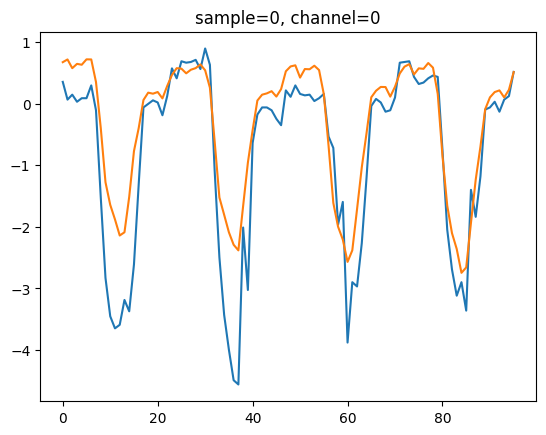

In [54]:
# 셀: pred/true npy quick plot
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

base = Path("/content/Time-o1/results/long_term_forecast_Fredformer_micro_bs1_amp_Fredformer_ETTh1_ftM_sl96_ll48_pl96_dm128_nh4_el1_dl1_df512_fc1_ebtimeF_dtTrue_ax0.0_rl0.0_axlMAE_mf1_test_0/pre_logs")
pred = np.load(base/"pred.npy")   # (N, pred_len, C)
true = np.load(base/"true.npy")

i = 0      # 샘플 인덱스
c = 0      # 채널(변수) 인덱스
plt.figure()
plt.plot(true[i,:,c])
plt.plot(pred[i,:,c])
plt.title(f"sample={i}, channel={c}")
plt.show()
